# Day 13 of ML 30-Days Challenge

# Task

**Polynomial Regression**: Learn to model non-linear relationships by creating polynomial features. Explore how model complexity relates to the bias-variance tradeoff and the risk of overfitting the training data.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

###1. Creating and Visualizing Non-Linear Data

In [40]:
np.random.seed(42)

X = np.linspace(-3, 3, 200).reshape(-1, 1)

noise = np.random.normal(0, 1.0, size=X.shape[0])
y = 2 * X.squeeze()**2 + 3 * X.squeeze() + noise

df = pd.DataFrame({"X": X.squeeze(), "y": y})
print("Head of dataset:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

Head of dataset:
          X         y
0 -3.000000  9.496714
1 -2.969849  8.592197
2 -2.939698  9.112248
3 -2.909548  9.725323
4 -2.879397  7.709510

Dataset shape: (200, 2)


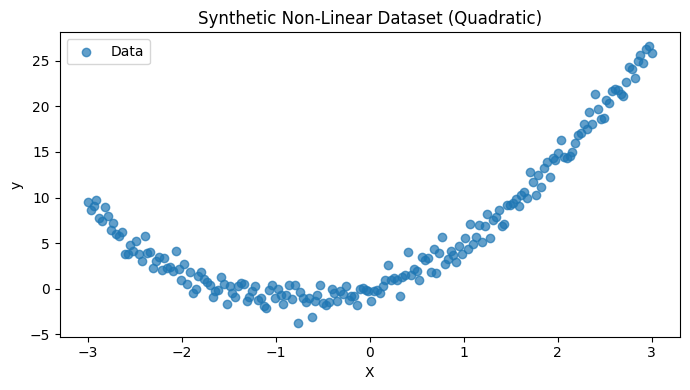

In [41]:
plt.figure(figsize=(7, 4))
plt.scatter(X, y, alpha=0.7, label="Data")
plt.title("Synthetic Non-Linear Dataset (Quadratic)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
degree = 8  # well you can try 1, 2, 3, 5...

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Original X shape: {X.shape}")
print(f"Transformed X_poly shape (degree={degree}): {X_poly.shape}")
print("First row of X_poly:", X_poly[0])

Original X shape: (200, 1)
Transformed X_poly shape (degree=8): (200, 8)
First row of X_poly: [-3.000e+00  9.000e+00 -2.700e+01  8.100e+01 -2.430e+02  7.290e+02
 -2.187e+03  6.561e+03]


###3. Training the Regression Model on Polynomial Features

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.25, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

###4. Evaluate

In [44]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nPolynomial degree: {degree}")
print(f"Train MSE: {train_mse:.4f}, R^2: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, R^2: {test_r2:.4f}")
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)


Polynomial degree: 8
Train MSE: 0.8212, R^2: 0.9860
Test  MSE: 0.8760, R^2: 0.9842
Model coefficients: [ 2.75716820e+00  1.68779133e+00  1.47960051e-01  2.04850400e-01
 -1.21127773e-02 -3.92114680e-02 -4.88590828e-04  2.26951712e-03]
Model intercept: -0.009902766852046163


###5. Visualizing the Polynomial Regression Curve

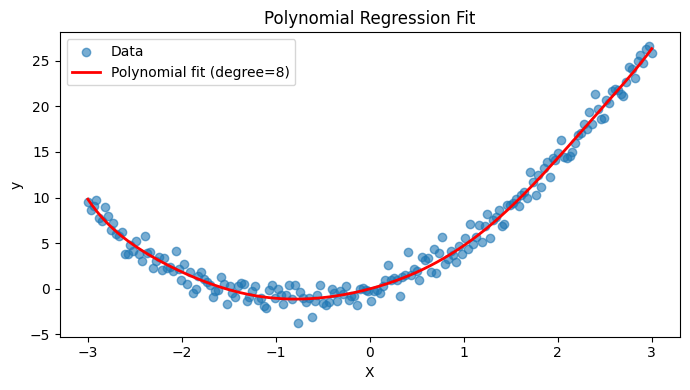

In [45]:
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)

y_plot = model.predict(X_plot_poly)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X_plot, y_plot, color="red", linewidth=2, label=f"Polynomial fit (degree={degree})")
plt.title("Polynomial Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

###Explore bias-variance by comparing degrees

In [46]:
degrees_to_try = [1, 2, 3, 5, 8]
results = []

for d in degrees_to_try:
    poly_d = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_d = poly_d.fit_transform(X)

    Xtr, Xte, ytr, yte = train_test_split(X_poly_d, y, test_size=0.25, random_state=42)
    m = LinearRegression().fit(Xtr, ytr)
    ytr_pred = m.predict(Xtr)
    yte_pred = m.predict(Xte)

    results.append({
        "degree": d,
        "train_mse": mean_squared_error(ytr, ytr_pred),
        "test_mse": mean_squared_error(yte, yte_pred),
        "train_r2": r2_score(ytr, ytr_pred),
        "test_r2": r2_score(yte, yte_pred),
    })

results_df = pd.DataFrame(results)
print("\nBias-Variance Exploration by Degree:")
print(results_df)


Bias-Variance Exploration by Degree:
   degree  train_mse   test_mse  train_r2   test_r2
0       1  31.765735  25.068240  0.458631  0.547286
1       2   0.869116   0.841791  0.985188  0.984798
2       3   0.861702   0.837427  0.985314  0.984877
3       5   0.827258   0.843939  0.985901  0.984759
4       8   0.821218   0.876014  0.986004  0.984180
